## Structure Optimization

In [1]:
import veloxchem as vlx
molecule = vlx.Molecule.read_smiles('CCO')
basis = vlx.MolecularBasis.read(molecule, 'def2-svp')

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.filename = 'optimization'
scf_drv.xcfun = 'b3lyp'
scf_drv.dispersion = 'd4'
results = scf_drv.compute(molecule, basis)

opt_drv = vlx.OptimizationDriver(scf_drv)
opt_results = opt_drv.compute(molecule, basis, results)
opt_drv.show_convergence(opt_results)


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Restart from Checkpoint                                              
                   Convergence Accelerator         : Direct Inversion of Iterative Subspace                               
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

interactive(children=(IntSlider(value=7, description='step', max=7), Output()), _dom_classes=('widget-interact…

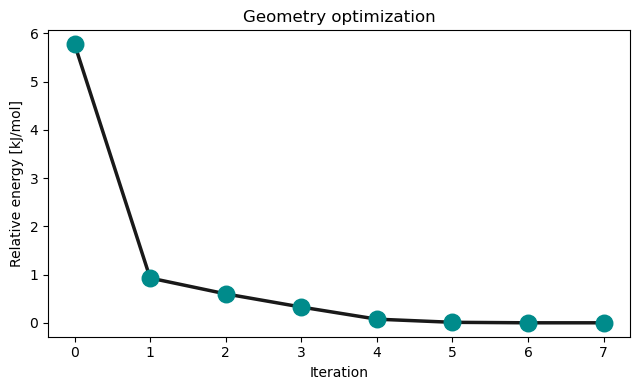

In [2]:
opt_drv.plot_convergence(opt_results)

## VALET (VIsual AnaLysis of Electronic Transitions)

In [3]:
thienyl_thiazole_xyz = """
15

C             -2.166567672964         0.313202106795        -1.071674934650
C             -2.080411655087         1.658890748544        -0.754536692329
S             -0.554021170961         2.069421191262        -0.054372064726
C              0.002025319127         0.415293509320        -0.177856865671
C             -0.978159137707        -0.398203353705        -0.742960550357
C              1.334466165114         0.091357832688         0.289886892105
N              2.176716511993         0.963152548206         0.810542073077
C              3.356151631070         0.369308861442         1.160279723016
C              3.449348155576        -0.988023484243         0.913955708515
S              1.977540876713        -1.559099336277         0.203328303396
H             -3.055949212391        -0.148672419644        -1.526305288569
H             -2.841345775207         2.438956152932        -0.896843728791
H             -0.837203807959        -1.476941876284        -0.913086590031
H              4.157887013088         0.976925929313         1.609453961619
H              4.288034413777        -1.669818398859         1.108225187542
"""



molecule = vlx.Molecule.from_xyz_string(thienyl_thiazole_xyz)
basis = vlx.MolecularBasis.read(molecule, "def2-sv(p)")

molecule.show(atom_indices=True)



3Dmol.js failed to load for some reason. Please check your browser console for error messages.

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

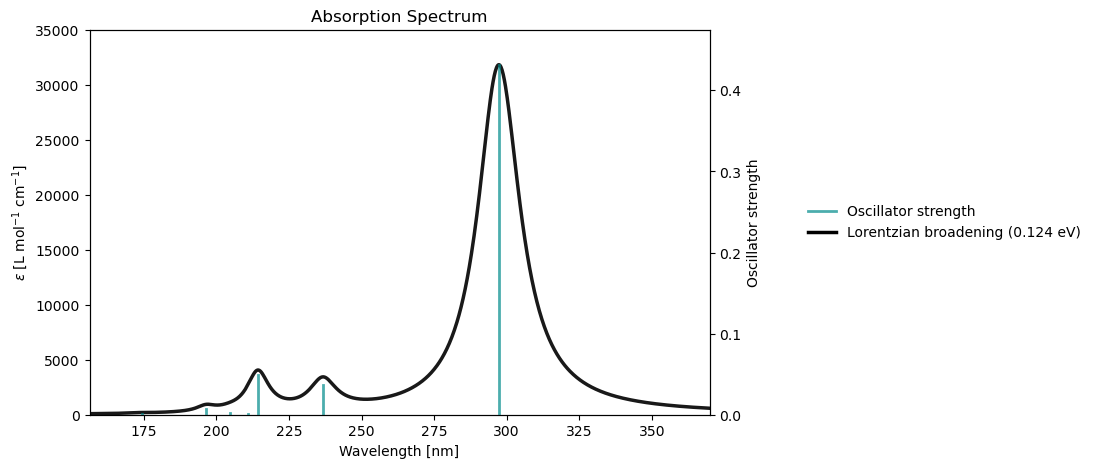

In [4]:
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_drv.filename = "thienyl_thiazole"

scf_results = scf_drv.compute(molecule, basis)

lr_drv = vlx.LinearResponseEigenSolver()
lr_drv.nstates = 10
lr_results = lr_drv.compute(molecule, basis, scf_results)

lr_drv.plot_uv_vis(lr_results)

In [5]:
fragment_dict = {}
fragment_dict["thienyl"] = [1, 2, 3, 4, 5, 11, 12, 13]
fragment_dict["thiazole"] = [6, 7, 8, 9, 10, 14, 15]

In [6]:
valet_drv = vlx.ValetAnalyzer()

# Optionally adjust visualization settings
valet_drv.density_isovalue = 0.001
valet_drv.density_opacity = 0.7

# Define fragment groups (1-based indexing)
# Each tuple is (name, atom_index) or (name, [list_of_atom_indices])
subgroups = [
    ('thienyl', fragment_dict["thienyl"]),
    ('thiazole', fragment_dict["thiazole"])
]

valet_drv.initialize(molecule, basis, subgroups)

# Show the interactive viewer
valet_drv.show(scf_results, lr_results)

Molecule: 15 atoms
Basis: DEF2-SV(P)
Visualizing 10 excited states


Dropdown(description='State:', options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10), value=1)